# EDA with Standardized Seaborn Configuration
## Using Custom Style Configuration Module

## 1. Import and Initialize Configuration

In [1]:
# Import the configuration module (make sure seaborn_config.py is in same directory)
from seaborn_config import *
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

✓ Seaborn configuration applied successfully!
Seaborn Configuration Module Loaded
Style: whitegrid | Context: notebook
Color Palette: husl
Font Family: sans-serif
Title Font Size: 16pt | Label Font Size: 12pt


## 2. Sample Data Creation
Creating sample print time data for demonstration

In [2]:
# Create sample experimental dataset
np.random.seed(42)
n_samples = 100

df = pd.DataFrame({
    'print_time_actual': np.random.normal(loc=45, scale=15, size=n_samples),
    'print_time_slicer': np.random.normal(loc=42, scale=12, size=n_samples),
    'material': np.random.choice(['PLA', 'ABS', 'PETG'], n_samples),
    'temperature': np.random.normal(loc=210, scale=20, size=n_samples),
    'bed_temp': np.random.normal(loc=60, scale=10, size=n_samples),
})

# Ensure positive values
df['print_time_actual'] = df['print_time_actual'].abs()
df['print_time_slicer'] = df['print_time_slicer'].abs()

print(df.head())
print(f"\nDataset shape: {df.shape}")

   print_time_actual  print_time_slicer material  temperature   bed_temp
0          52.450712          25.015551      ABS   203.212274  66.475581
1          42.926035          36.952256      ABS   193.694581  65.360265
2          54.715328          37.887426      PLA   223.981848  68.401712
3          67.845448          32.372673      PLA   221.997933  71.333420
4          41.487699          40.064571      PLA   200.375037  54.602546

Dataset shape: (100, 5)


## 3. Single Plot Examples

### Example 1: Simple Histogram with Standardized Styling

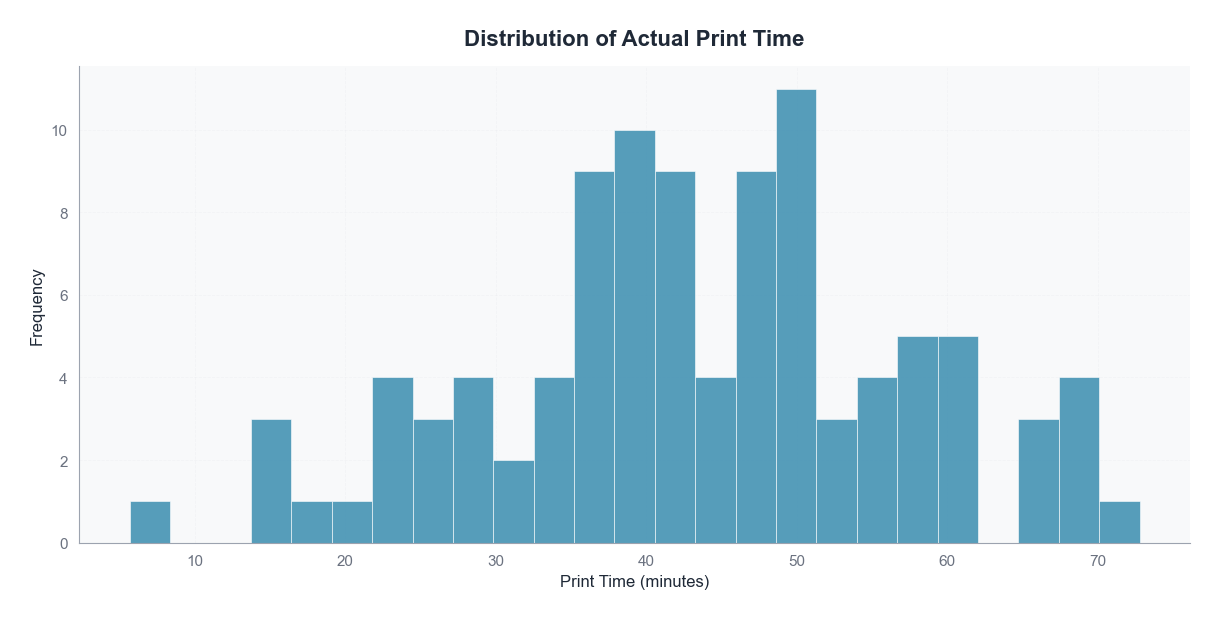

In [3]:
# Method 1: Using helper function (quickest)
fig, ax = plot_histogram(
    data=df['print_time_actual'],
    title='Distribution of Actual Print Time',
    xlabel='Print Time (minutes)',
    bins=25
)
plt.show()

### Example 2: Manual Plot with Full Control

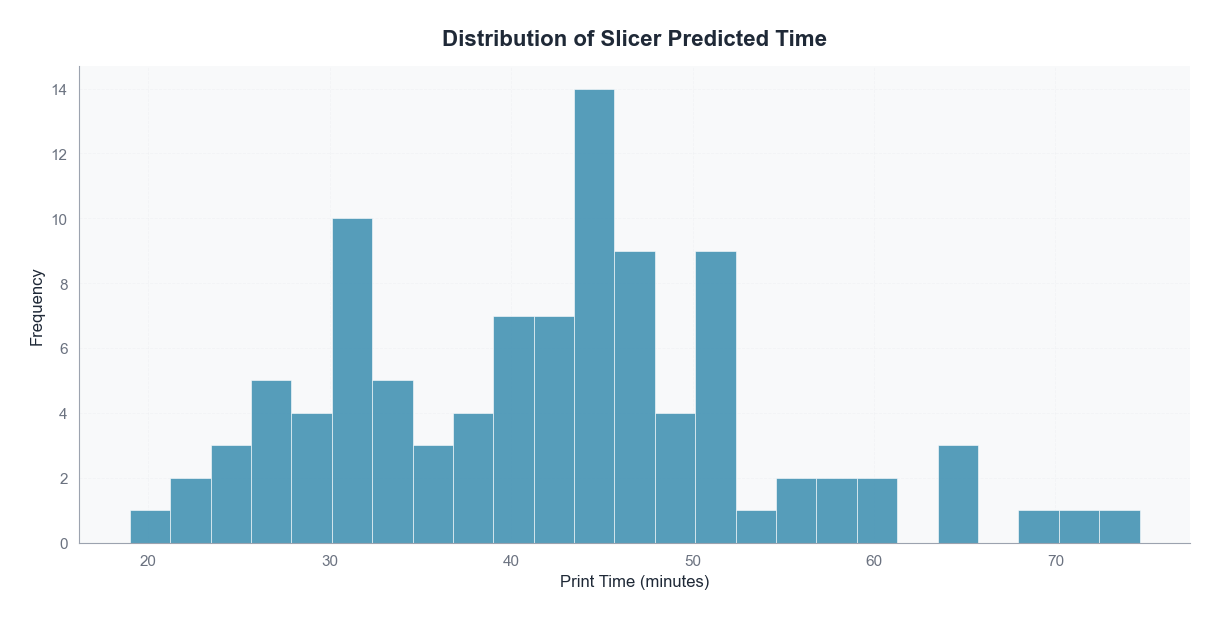

In [4]:
# Method 2: Manual creation with more control
fig, ax = get_figure_and_axes(plot_type='medium')  # Uses FIGURE_SIZES['medium']

# Create the plot
ax.hist(df['print_time_slicer'], bins=25, edgecolor='white', alpha=0.8, color=ACCENT_COLOR)

# Apply standardized styling
set_title_and_labels(
    ax,
    title='Distribution of Slicer Predicted Time',
    xlabel='Print Time (minutes)',
    ylabel='Frequency',
    fontsize_title=FONT_SIZES['title'],
    fontsize_label=FONT_SIZES['label']
)

style_axes(ax, remove_spines=['top', 'right'])

plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

### Example 3: Scatter Plot

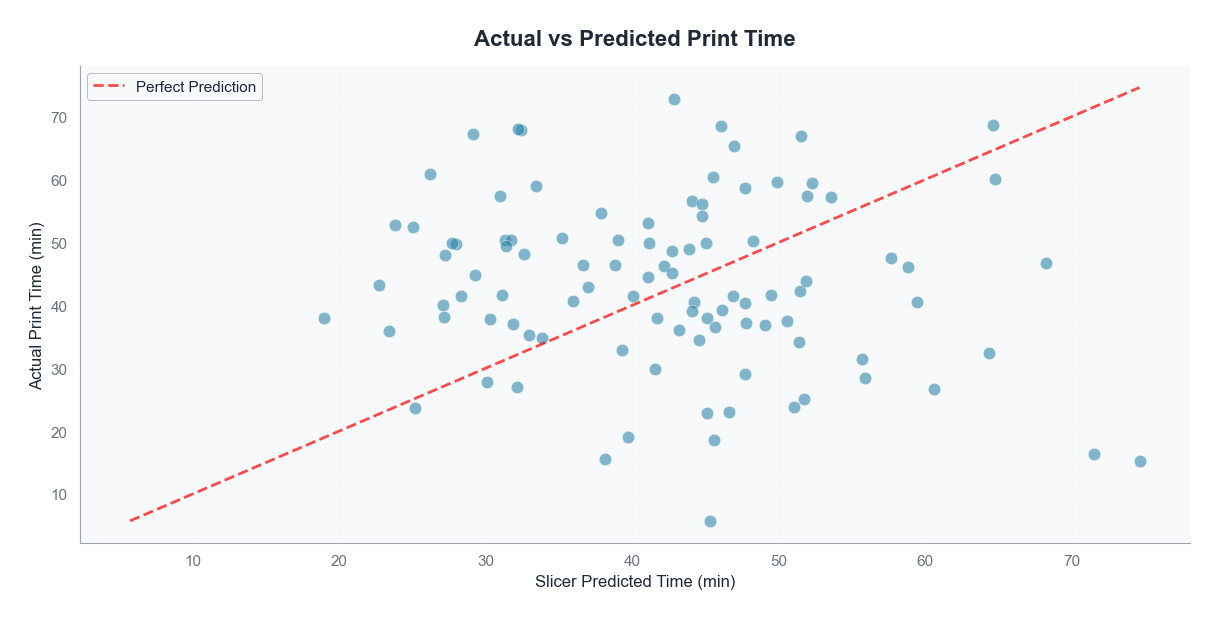

In [5]:
fig, ax = plot_scatter(
    x=df['print_time_slicer'],
    y=df['print_time_actual'],
    title='Actual vs Predicted Print Time',
    xlabel='Slicer Predicted Time (min)',
    ylabel='Actual Print Time (min)'
)

# Add a perfect prediction line
min_val = min(df['print_time_slicer'].min(), df['print_time_actual'].min())
max_val = max(df['print_time_slicer'].max(), df['print_time_actual'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction', linewidth=2, alpha=0.7)

add_legend(ax, loc='upper left')
plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

## 4. Multi-Plot Examples

### Example 4: Two Plots Side by Side

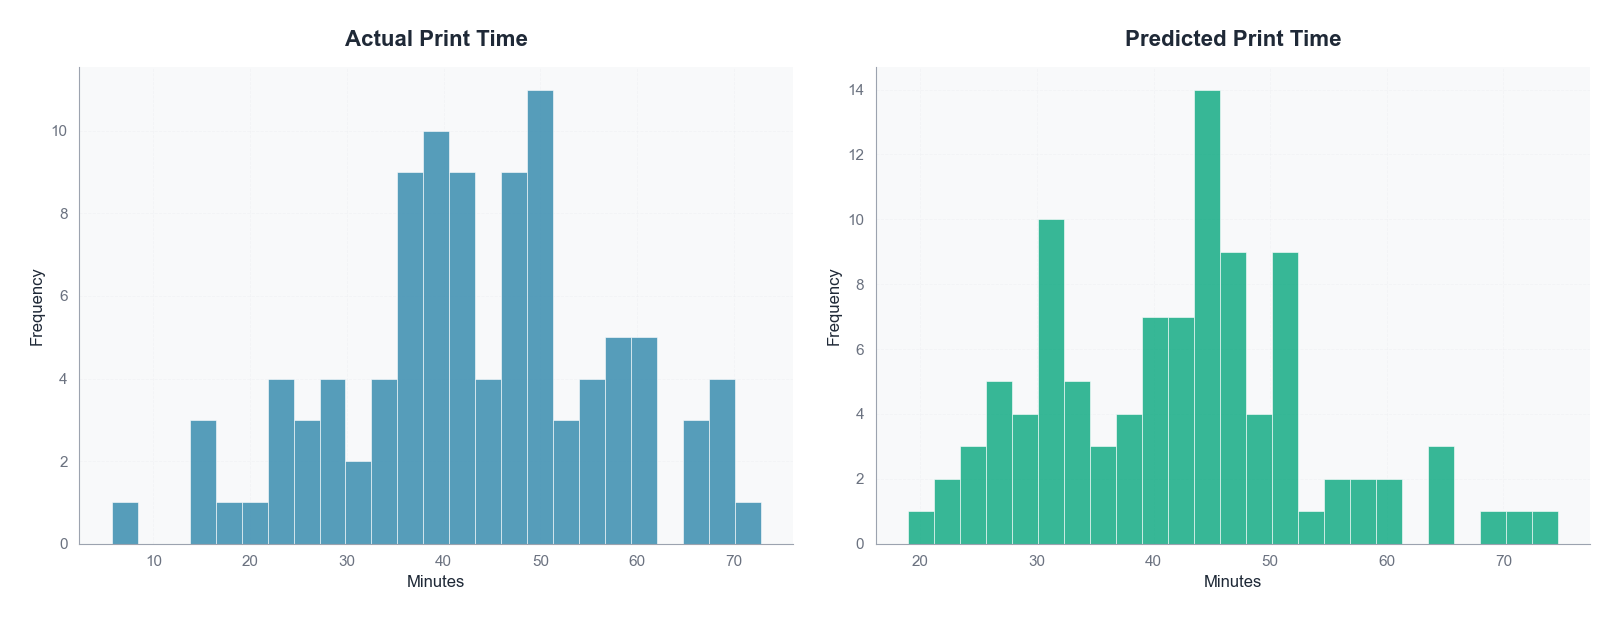

In [6]:
fig, axes = get_figure_and_axes(plot_type='double_row', num_plots=2)

# Left plot
axes[0].hist(df['print_time_actual'], bins=25, edgecolor='white', alpha=0.8, color=ACCENT_COLOR)
set_title_and_labels(axes[0], title='Actual Print Time', xlabel='Minutes', ylabel='Frequency')
style_axes(axes[0])

# Right plot
axes[1].hist(df['print_time_slicer'], bins=25, edgecolor='white', alpha=0.8, color=SUCCESS_COLOR)
set_title_and_labels(axes[1], title='Predicted Print Time', xlabel='Minutes', ylabel='Frequency')
style_axes(axes[1])

plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

### Example 5: Three Plots in a Row

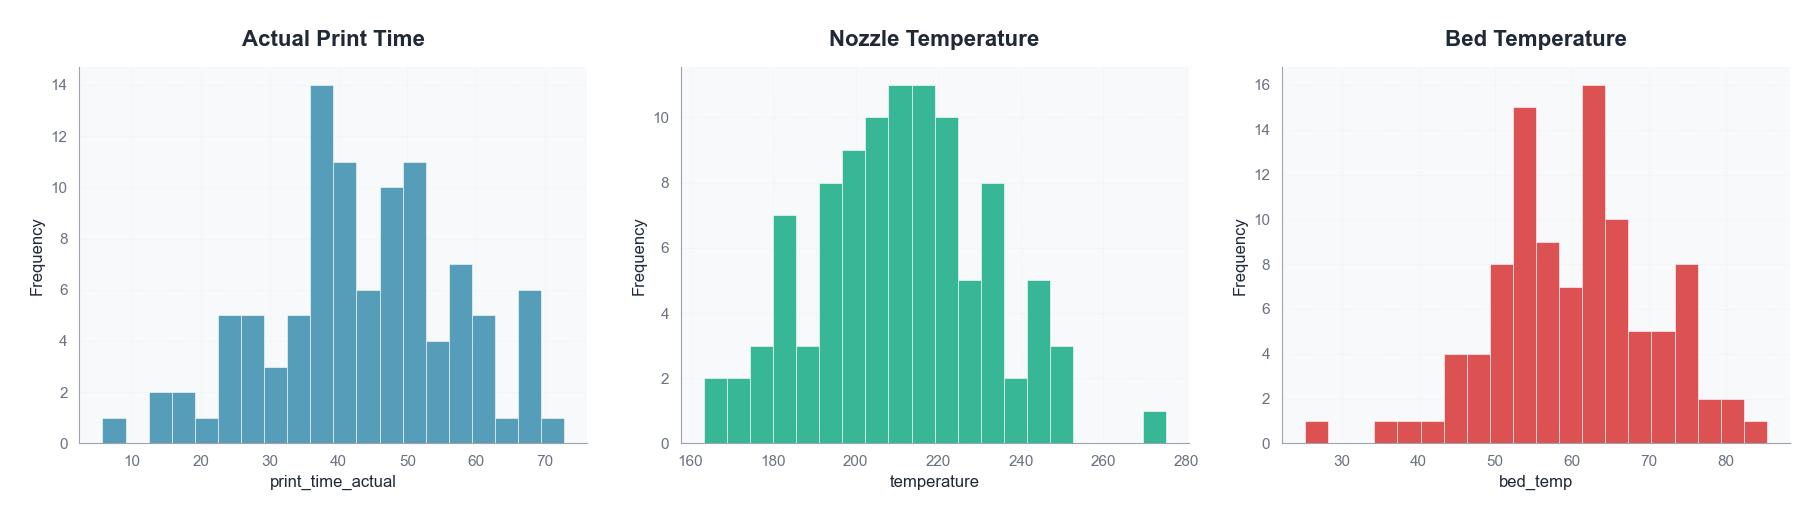

In [7]:
fig, axes = get_figure_and_axes(plot_type='triple_row', num_plots=3)

columns = ['print_time_actual', 'temperature', 'bed_temp']
colors = [ACCENT_COLOR, SUCCESS_COLOR, WARNING_COLOR]
titles = ['Actual Print Time', 'Nozzle Temperature', 'Bed Temperature']

for idx, (ax, col, color, title) in enumerate(zip(axes, columns, colors, titles)):
    ax.hist(df[col], bins=20, edgecolor='white', alpha=0.8, color=color)
    set_title_and_labels(ax, title=title, xlabel=col, ylabel='Frequency')
    style_axes(ax)

plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

### Example 6: 2x2 Grid

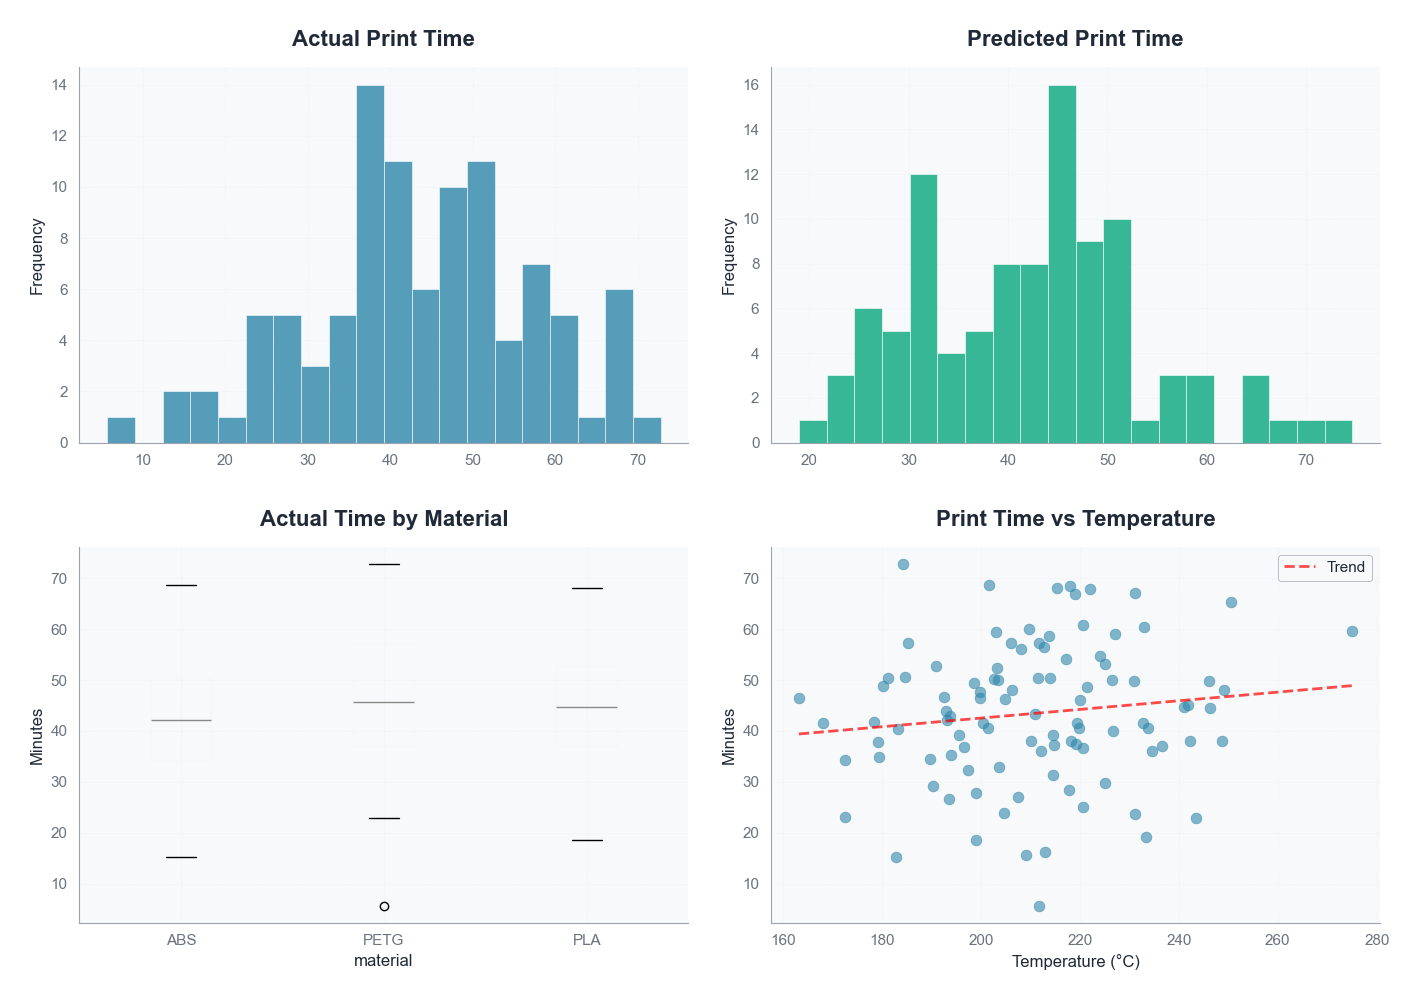

In [8]:
fig, axes = get_figure_and_axes(plot_type='grid_2x2', num_plots=4, layout=(2, 2))
axes = axes.flatten()  # Flatten to 1D array

# Plot 1: Actual time distribution
axes[0].hist(df['print_time_actual'], bins=20, edgecolor='white', alpha=0.8, color=ACCENT_COLOR)
set_title_and_labels(axes[0], title='Actual Print Time', ylabel='Frequency')
style_axes(axes[0])

# Plot 2: Predicted time distribution
axes[1].hist(df['print_time_slicer'], bins=20, edgecolor='white', alpha=0.8, color=SUCCESS_COLOR)
set_title_and_labels(axes[1], title='Predicted Print Time', ylabel='Frequency')
style_axes(axes[1])

# Plot 3: Box plot by material
df.boxplot(column='print_time_actual', by='material', ax=axes[2])
set_title_and_labels(axes[2], title='Actual Time by Material', ylabel='Minutes')
axes[2].get_figure().suptitle('')  # Remove automatic title
style_axes(axes[2])

# Plot 4: Scatter with regression
axes[3].scatter(df['temperature'], df['print_time_actual'], alpha=0.6, s=60, color=ACCENT_COLOR)
z = np.polyfit(df['temperature'], df['print_time_actual'], 1)
p = np.poly1d(z)
axes[3].plot(df['temperature'].sort_values(), p(df['temperature'].sort_values()), "r--", linewidth=2, alpha=0.7, label='Trend')
set_title_and_labels(axes[3], title='Print Time vs Temperature', xlabel='Temperature (°C)', ylabel='Minutes')
add_legend(axes[3])
style_axes(axes[3])

plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

## 5. Correlation Heatmap

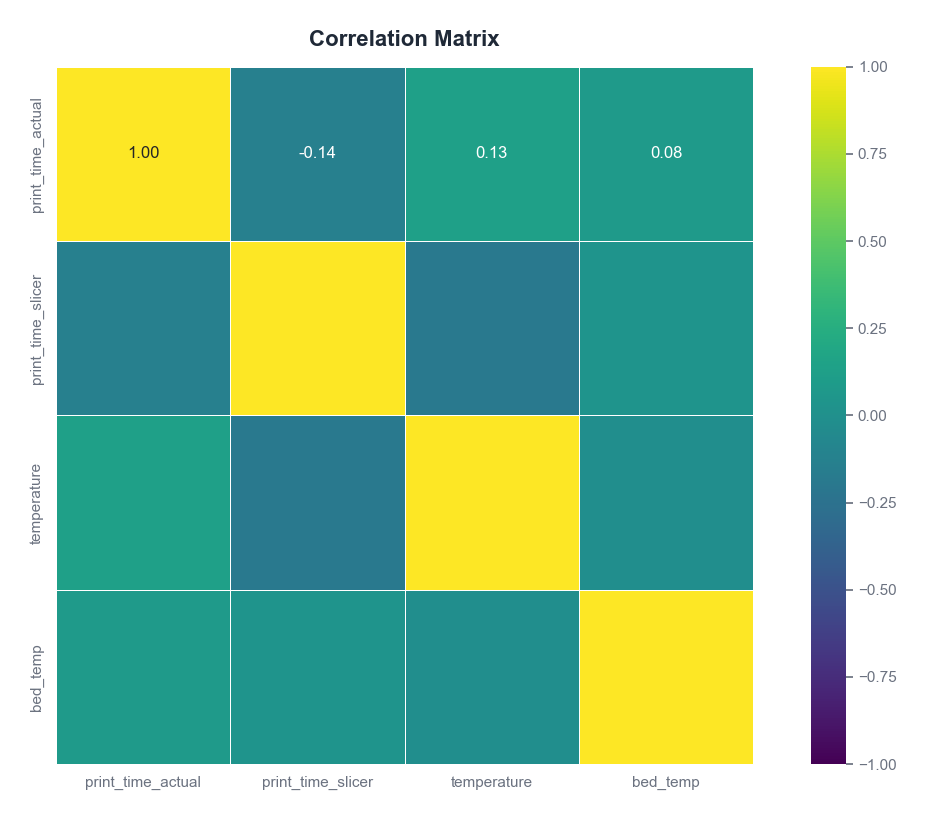

In [9]:
fig, ax = get_figure_and_axes(plot_type='heatmap')

# Calculate correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap=CONTINUOUS_CMAP,
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=-1,
    vmax=1,
    center=0
)

set_title_and_labels(ax, title='Correlation Matrix')
plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

## 6. Box Plot Comparison by Category

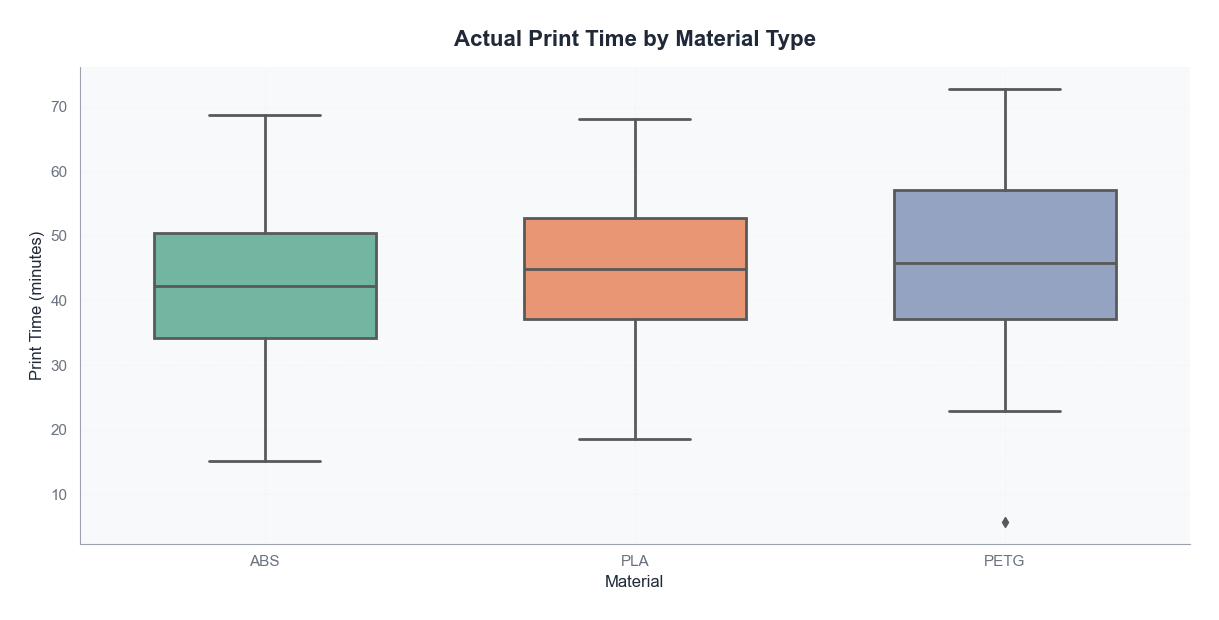

In [10]:
fig, ax = get_figure_and_axes(plot_type='boxplot')

# Using seaborn boxplot for better styling
sns.boxplot(
    data=df,
    x='material',
    y='print_time_actual',
    palette='Set2',
    ax=ax,
    width=0.6
)

set_title_and_labels(
    ax,
    title='Actual Print Time by Material Type',
    xlabel='Material',
    ylabel='Print Time (minutes)'
)
style_axes(ax)

plt.tight_layout(**TIGHT_LAYOUT_PARAMS)
plt.show()

## 7. Save Figures with Standardized Settings

FileNotFoundError: [Errno 2] No such file or directory: './output/histogram_example.png'

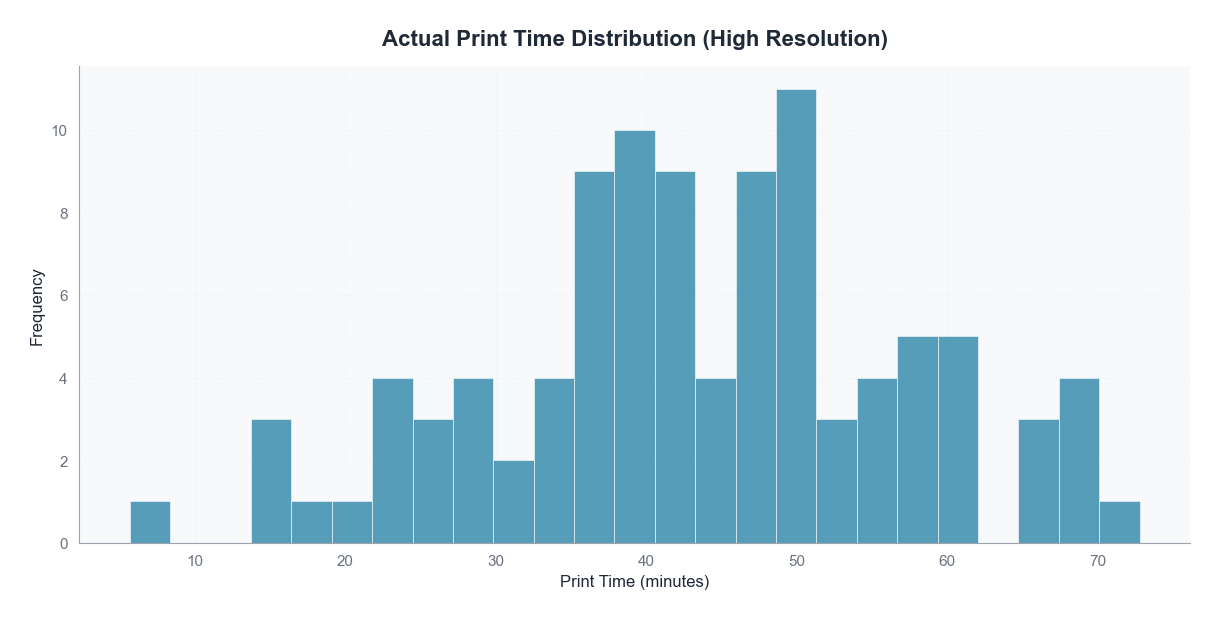

In [11]:
# Create and save a figure
fig, ax = plot_histogram(
    data=df['print_time_actual'],
    title='Actual Print Time Distribution (High Resolution)',
    xlabel='Print Time (minutes)',
    bins=25
)

# Save with high DPI
save_figure(fig, './output/histogram_example.png', dpi=DEFAULT_DPI, pad_inches=0.3)
plt.show()

## 8. Customizing the Configuration

✓ Seaborn configuration applied successfully!


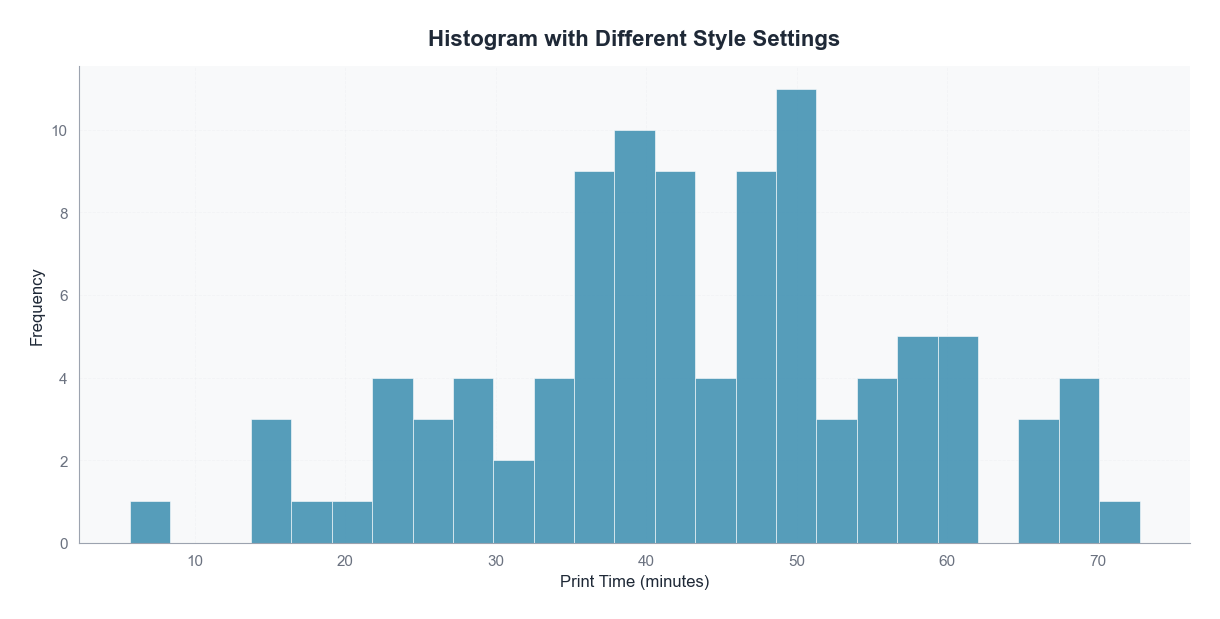

In [ ]:
# Change the global style without modifying seaborn_config.py

# Example: Use a different color palette and style
apply_style_config(
    style='white',        # Changed from 'whitegrid'
    context='talk',       # Larger fonts for presentations
    palette='Set2'        # Different color palette
)

# Now all new plots will use these settings
fig, ax = plot_histogram(
    data=df['print_time_actual'],
    title='Histogram with Different Style Settings',
    xlabel='Print Time (minutes)',
    bins=25
)
plt.show()

## 9. Font Size Reference

In [ ]:
# Display all configured font sizes
print("\n" + "="*70)
print("FONT SIZE STANDARDS")
print("="*70)

for style, size in FONT_SIZES.items():
    weight = FONT_WEIGHTS.get(style, 'normal')
    print(f"  {style:15} : {size:3}pt ({weight})")

print("\n" + "="*70)
print("FIGURE SIZE STANDARDS")
print("="*70)

for name, size in FIGURE_SIZES.items():
    print(f"  {name:15} : {size}")

print("\n" + "="*70)
print("COLOR REFERENCES")
print("="*70)
print(f"  Accent Color    : {ACCENT_COLOR}")
print(f"  Success Color   : {SUCCESS_COLOR}")
print(f"  Warning Color   : {WARNING_COLOR}")
print(f"  Info Color      : {INFO_COLOR}")
print(f"  Neutral Color   : {NEUTRAL_COLOR}")
print("="*70)


FONT SIZE STANDARDS
  title           :  16pt (bold)
  subtitle        :  14pt (semibold)
  label           :  12pt (normal)
  tick            :  11pt (normal)
  legend          :  11pt (normal)
  annotation      :  10pt (normal)
  caption         :   9pt (normal)

FIGURE SIZE STANDARDS
  small           : (8, 5)
  medium          : (12, 6)
  large           : (14, 8)
  wide            : (16, 5)
  tall            : (10, 10)
  square          : (10, 10)
  double_row      : (16, 6)
  triple_row      : (18, 5)
  grid_2x2        : (14, 10)
  grid_2x3        : (16, 10)
  grid_3x3        : (16, 12)
  heatmap         : (12, 8)
  distribution    : (12, 5)
  boxplot         : (12, 6)
  violin          : (14, 7)
  scatter         : (10, 8)
  histogram       : (12, 6)
  barplot         : (12, 6)
  line            : (14, 6)

COLOR REFERENCES
  Accent Color    : #2E86AB
  Success Color   : #06A77D
  Warning Color   : #D62828
  Info Color      : #F77F00
  Neutral Color   : #6C757D


## Summary

This notebook demonstrates how to use the standardized Seaborn configuration module. Key benefits:

✅ **Consistency**: All plots have uniform font sizes, colors, and styling  
✅ **Readability**: Professional font choices and clear visual hierarchy  
✅ **Maintainability**: Change global settings in one place, affects all plots  
✅ **Efficiency**: Use helper functions for quick plot creation  
✅ **Flexibility**: Override defaults when needed for specific plots  

### Quick Tips:
- Use `get_figure_and_axes()` for consistent figure sizes
- Use `set_title_and_labels()` for consistent font sizing
- Use `style_axes()` for consistent axis styling
- Use `add_legend()` for consistent legend formatting
- Use `save_figure()` for consistent export settings